# Quickstart

In [1]:
import immunowave as iw
import diffrax as dx
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

## Define a model

### FitzHugh-Nagumo + Bacteria

The dynamical variables $(A, B, R)$ denote
the concentration of antimicrobial peptide, bacteria, and repression, respectively.

First we define a state by subclassing the abstract class `immunowave.State`.

In [2]:
class FHNB_state(iw.State):
    A: iw.ScalarField
    B: iw.ScalarField
    R: iw.ScalarField

Our dynamical field variables satisfy
$$
\begin{align*}
\partial_t A &= \alpha \nabla^2 A + A (A - \theta) (1 - A) + \eta B - \rho R \\
\partial_t B &= \xi \nabla^2 B + \lambda B (1-B) - \mu A B\\
\partial_t R &= \epsilon (A - R)
\end{align*}
$$

Parameters:
- $\alpha$: Diffusion coefficient of antimicrobial peptide.
- $\theta$: Threshold for antimicrobial peptide production.
- $\eta$: Rate of antimicrobial peptide growth response to bacteria.
- $\rho$: Rate of antimicrobial peptide degradation response to repression.
- $\epsilon$: Rate of repression production.
- $\xi$: Diffusion coefficient of bacteria.
- $\lambda$: Rate of bacteria growth.
- $\mu$: Rate of bacteria death response to antimicrobial peptide.
    

Models are defined by subclassing the abstract class `immunowave.Model`, and implementing the right-hand side of the dynamical system by overriding the method `immunowave.Model.__call__`.

In [3]:
class FHNB_model(iw.Model):
    α: float
    θ: float
    η: float
    ρ: float
    ε: float
    ξ: float
    λ: float
    μ: float

    def __call__(self, t, state, args=None):
        # unpack field variables
        A, B, R = state.A, state.B, state.R
        # unpack parameters
        α, θ, η, ρ, ε, ξ, λ, μ = (
            self.α,
            self.θ,
            self.η,
            self.ρ,
            self.ε,
            self.ξ,
            self.λ,
            self.μ,
        )
        # define PDE
        dAdt = α * A.laplacian(bc="neumann") + A * (A - θ) * (1 - A) + η * B - ρ * R
        dBdt = ξ * B.laplacian(bc="neumann") + λ * B * (1 - B) - μ * A * B
        dRdt = ε * (A - R)

        return FHNB_state(dAdt, dBdt, dRdt)

Instantiate the model

In [4]:
model = FHNB_model(α=1.0, θ=0.1, η=10.0, ρ=0.5, ε=0.1, ξ=0.1, λ=0.9, μ=0.1)
model

FHNB_model(α=1.0, θ=0.1, η=10.0, ρ=0.5, ε=0.1, ξ=0.1, λ=0.9, μ=0.1)

## Initialize fields

Spatial discretization

In [5]:
L = 20.0
n = 200

shape = (n,)
lb = [0]
h = L / (n - 1)

Initialize the $A$ and $R$ fields to zero and the $B$ field to a finite impulse at the center of the domain.

In [6]:
state = FHNB_state(
    A=iw.ScalarField(shape, lb, h, 0),
    B=iw.ScalarField(
        shape, lb, h, fn=lambda x: 1 * jnp.exp(-((x - L / 2) ** 2) / (2 * 0.1**2))
    ),
    R=iw.ScalarField(shape, lb, h, 0),
)

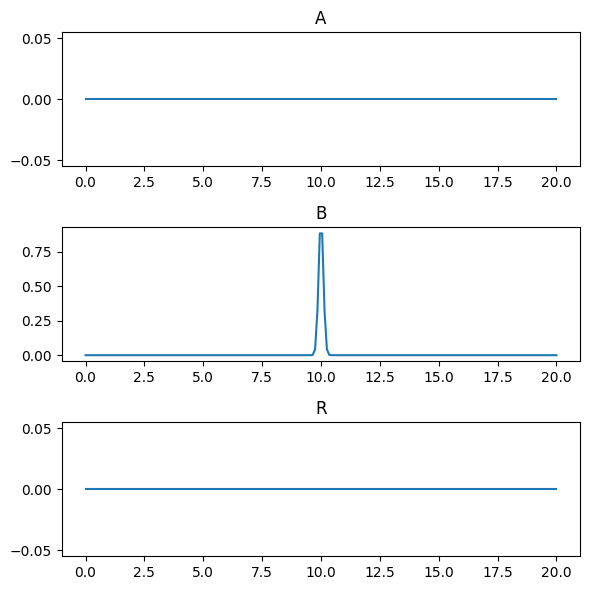

In [7]:
axes = state.plot()
plt.show()

## Solve

Define integration region

In [8]:
t0 = 0.0
t1 = 30.0

Keyword arguments for the solver

In [9]:
atol = 1e-6
rtol = 1e-6

kwargs = dict(
    dt0=1e-4,
    max_steps=10000000,
    atol=atol,
    rtol=rtol,
    throw=True,
    saveat=dx.SaveAt(dense=True),
)

Solve

In [10]:
solution = iw.solve(model, state, t0, t1, **kwargs)

## Plot

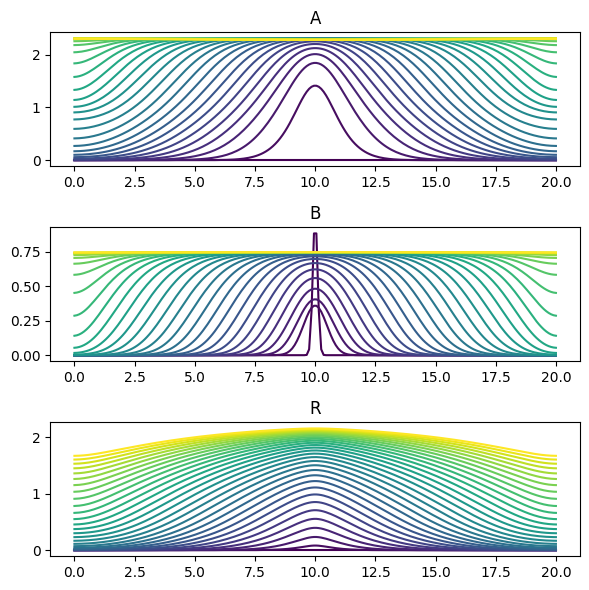

In [11]:
for axis in axes:
    axis.clear()
cmap = plt.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=t0, vmax=t1), cmap=plt.cm.viridis
)
for t in np.linspace(t0, t1, int(t1 - t0) + 1):
    axes = solution.evaluate(t).plot(axes=axes, color=cmap.to_rgba(t))

plt.show()

## 2D example

It is straightforward to extend the model to 2D or 3D.
In fact, we can use the same model instance and state class as above, but change the state instance to a 2D or 3D domain. For 2D we update the domain parameters to:

In [12]:
shape = (n, n)
lb = [0, 0]
h = L / (n - 1)

In [13]:
state = FHNB_state(
    A=iw.ScalarField(shape, lb, h, 0),
    B=iw.ScalarField(
        shape,
        lb,
        h,
        fn=lambda x, y: jnp.exp(-((x - L / 2) ** 2 + (y - L / 2) ** 2) / (2 * 0.1**2)),
    ),
    R=iw.ScalarField(shape, lb, h, 0),
)

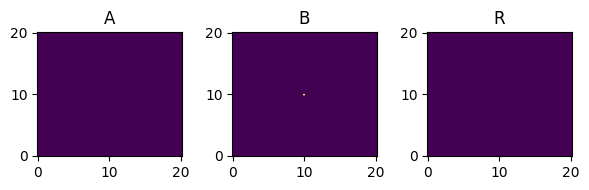

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(0.1 * 3 * L, 0.1 * L))
state.plot(axes=axes)
plt.show()

In [15]:
time_grid = np.linspace(t0, t1, 11)
solution = iw.solve(
    model, state, t0, t1, dt0=1e-2, max_steps=100000, saveat=dx.SaveAt(ts=time_grid)
)

time_point=0.0


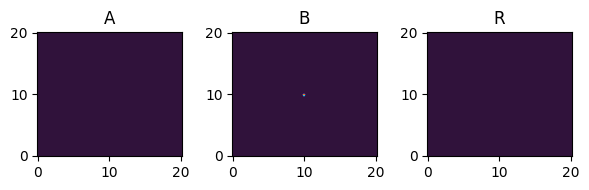

time_point=3.0


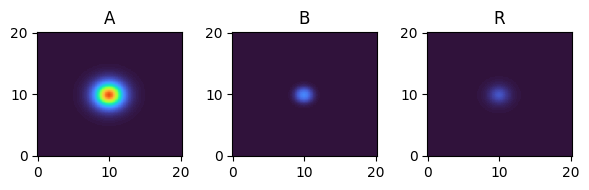

time_point=6.0


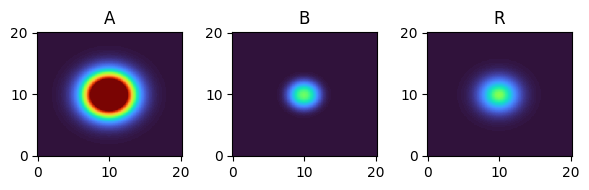

time_point=9.0


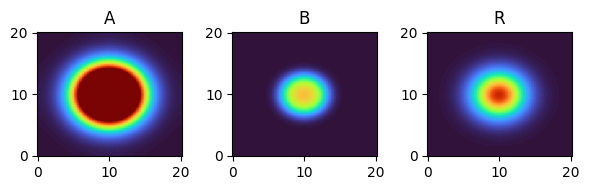

time_point=12.0


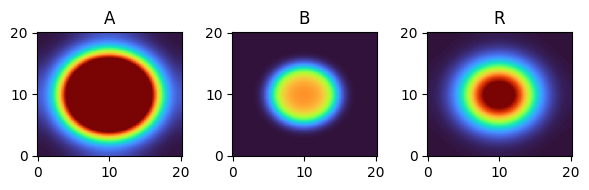

time_point=15.0


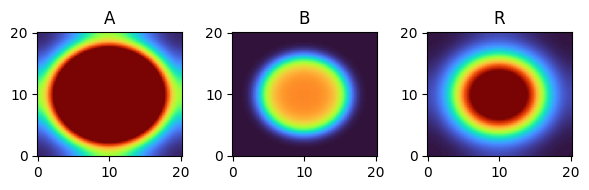

time_point=18.0


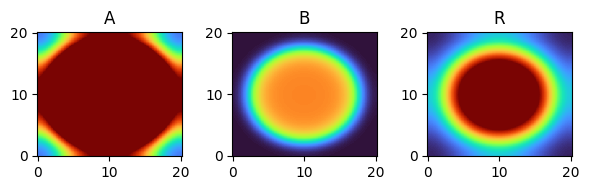

time_point=21.0


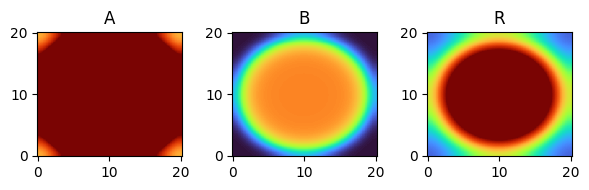

time_point=24.0


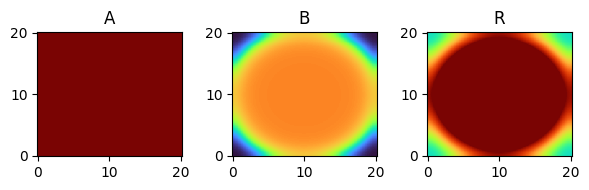

time_point=27.0


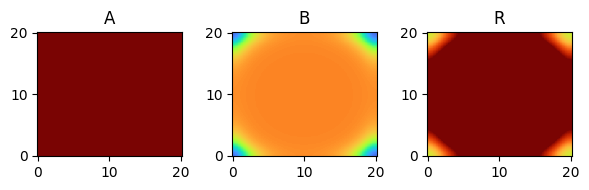

time_point=30.0


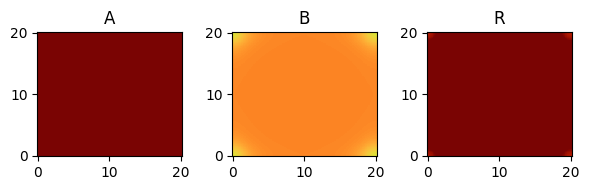

In [16]:
for i, time_point in enumerate(time_grid):
    print(f"{time_point=}")
    fig, axes = plt.subplots(1, 3, figsize=(6, 2))
    solution.ys.plot(time_idx=i, vmin=0, vmax=1, axes=axes, cmap="turbo")
    plt.show()